In [1]:
!pip install yfinance

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    LSTM,
    Dense,
    Dropout
)

In [17]:
data = yf.download(
    'TMPV.NS',
    start='2020-01-01',
    end='2025-01-01'
)


/tmp/ipykernel_20558/1215439100.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(
[*********************100%***********************]  1 of 1 completed


In [18]:
dataset = data[['Close']]

In [19]:
data.head()

Price,Close,High,Low,Open,Volume
Ticker,TMPV.NS,TMPV.NS,TMPV.NS,TMPV.NS,TMPV.NS
Date,,,,,
2020-01-01,181.187698,183.397903,180.352741,181.875315,25968357
2020-01-02,190.323227,191.256422,181.335065,181.727984,57289863
2020-01-03,187.720093,192.189607,185.902807,189.488245,47572728
2020-01-06,182.366486,187.621869,181.777107,187.621869,28621212
2020-01-07,181.433289,186.050159,179.075742,183.692612,34995035


In [20]:
scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(dataset)

In [21]:
X = []
y = []

sequence_length = 60

for i in range(sequence_length, len(scaled_data)):

    X.append(
        scaled_data[i-sequence_length:i]
    )

    y.append(
        scaled_data[i]
    )

X = np.array(X)
y = np.array(y)

In [22]:
train_size = int(len(X) * 0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]


In [23]:
model = Sequential()

# First LSTM Layer
model.add(
    LSTM(
        units=64,
        return_sequences=True,
        input_shape=(X_train.shape[1], 1)
    )
)

model.add(
    Dropout(0.2)
)

# Second LSTM Layer
model.add(
    LSTM(
        units=64
    )
)

model.add(
    Dropout(0.2)
)

# Dense Output Layer
model.add(
    Dense(1)
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [24]:
model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

In [25]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 6s 99ms/step - loss: 0.0096 - val_loss: 0.0066
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - loss: 0.0016 - val_loss: 0.0014
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - loss: 0.0012 - val_loss: 0.0014
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - loss: 0.0011 - val_loss: 0.0017
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - loss: 0.0010 - val_loss: 0.0013
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - loss: 0.0011 - val_loss: 0.0030
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 91ms/step - loss: 9.5885e-04 - val_loss: 0.0015
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - loss: 0.0010 - val_loss: 0.0012
Epoch 9/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - loss: 8.5395e-04 - val_loss: 0.0012
Epoch 10/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - loss: 9.0345e-04 - val_loss: 0.0013
Epoch 11/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - loss: 9.1401e-04 - val_loss: 0.0012
Epoch 12/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/

In [26]:
predictions = model.predict(X_test)

# Inverse scaling
predictions = scaler.inverse_transform(
    predictions
)

y_test_actual = scaler.inverse_transform(
    y_test
)

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step


In [27]:
rmse = np.sqrt(
    mean_squared_error(
        y_test_actual,
        predictions
    )
)

print("\nRMSE:", rmse)


RMSE: 35.58672405334559


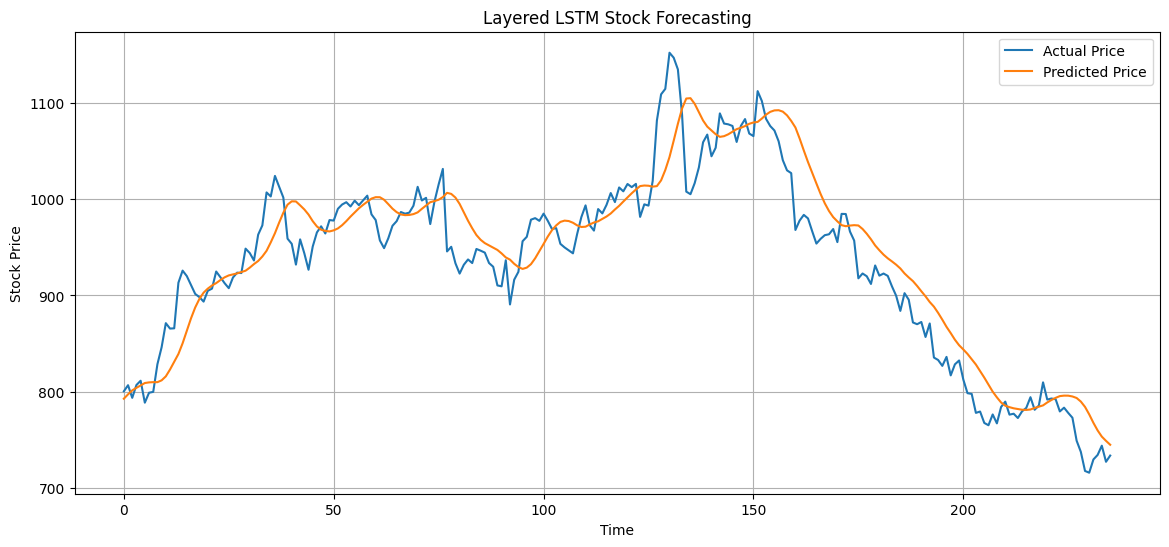

In [28]:
plt.figure(figsize=(14,6))

plt.plot(
    y_test_actual,
    label='Actual Price'
)

plt.plot(
    predictions,
    label='Predicted Price'
)

plt.title('Layered LSTM Stock Forecasting')

plt.xlabel('Time')

plt.ylabel('Stock Price')

plt.legend()

plt.grid(True)

plt.show()

In [29]:
last_60_days = scaled_data[-60:]

future_input = np.reshape(
    last_60_days,
    (1, 60, 1)
)

future_prediction = model.predict(
    future_input
)

future_prediction = scaler.inverse_transform(
    future_prediction
)

print(
    "\nNext Predicted Stock Price:",
    future_prediction[0][0]
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step

Next Predicted Stock Price: 742.0775
